In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX


📈 Section 1: Time Series Decomposition
----------------------------------------------------------------------

Time series component statistics:
  • Trend range: 164.43 to 384.00
  • Seasonal range: -33.68 to 61.59
  • Residual standard deviation: 63.75

----------------------------------------------------------------------
📊 Section 2: Stationarity Test
----------------------------------------------------------------------

Augmented Dickey-Fuller test for Users:
  • ADF Statistic: -3.5558
  • p-value: 0.0067
  • Critical Values:
      1%: -3.4692
      5%: -2.8786
      10%: -2.5759

  ✅ The time series is stationary (p-value < 0.05)

ADF test for differenced Users:
  • ADF Statistic: -4.9294
  • p-value: 0.0000
  ✅ The differenced series is stationary

----------------------------------------------------------------------
📊 Section 4: Rolling Statistics
----------------------------------------------------------------------

Rolling statistics:
  • Rolling mean shows the overall tre

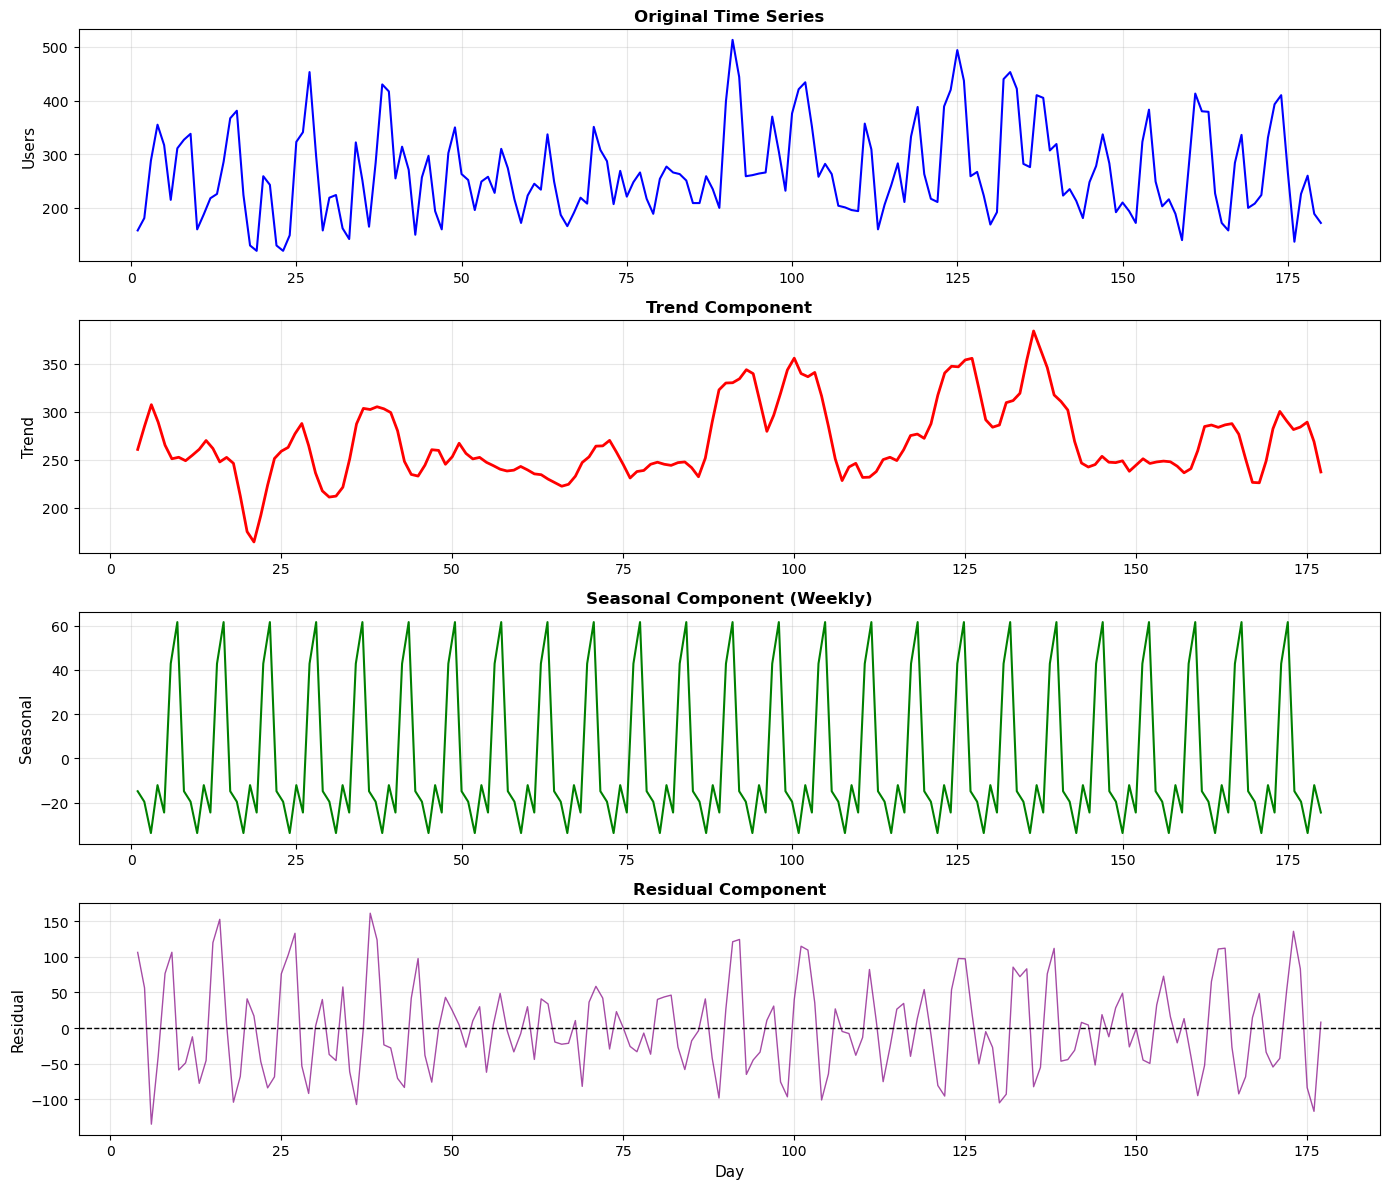

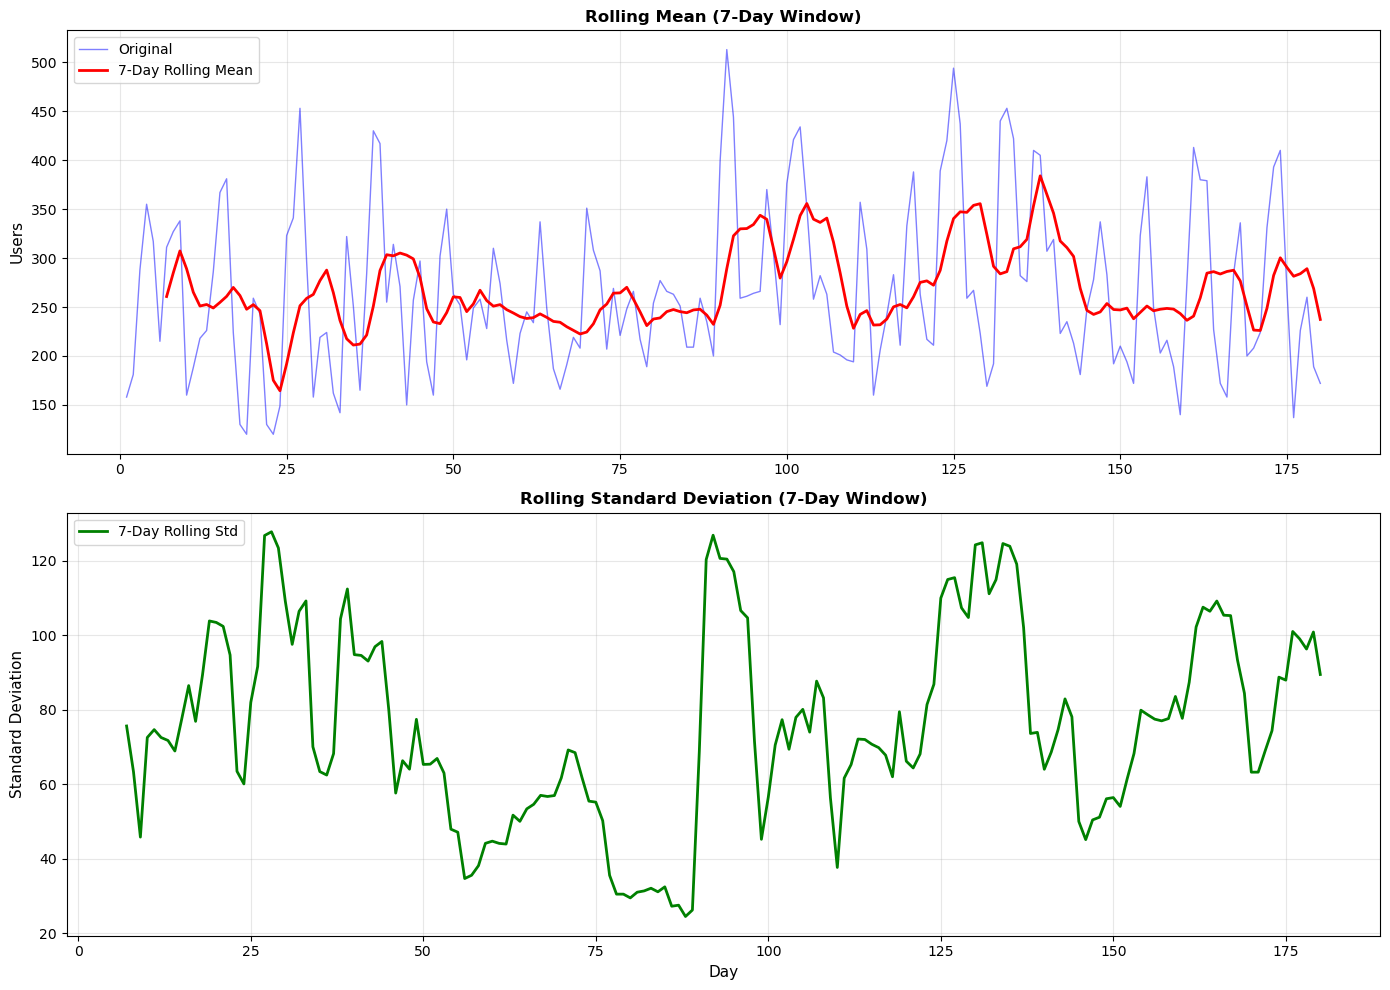

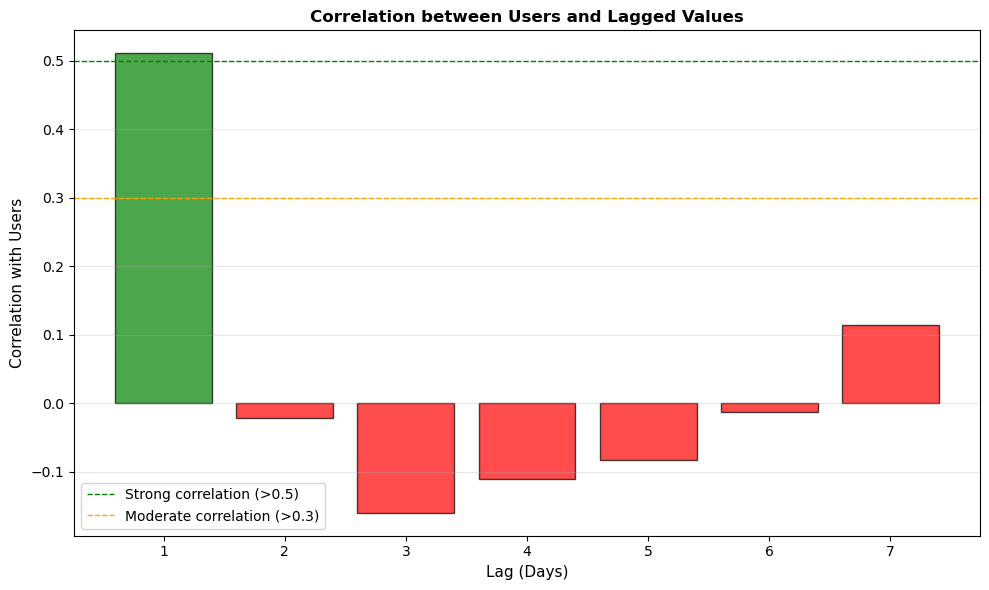

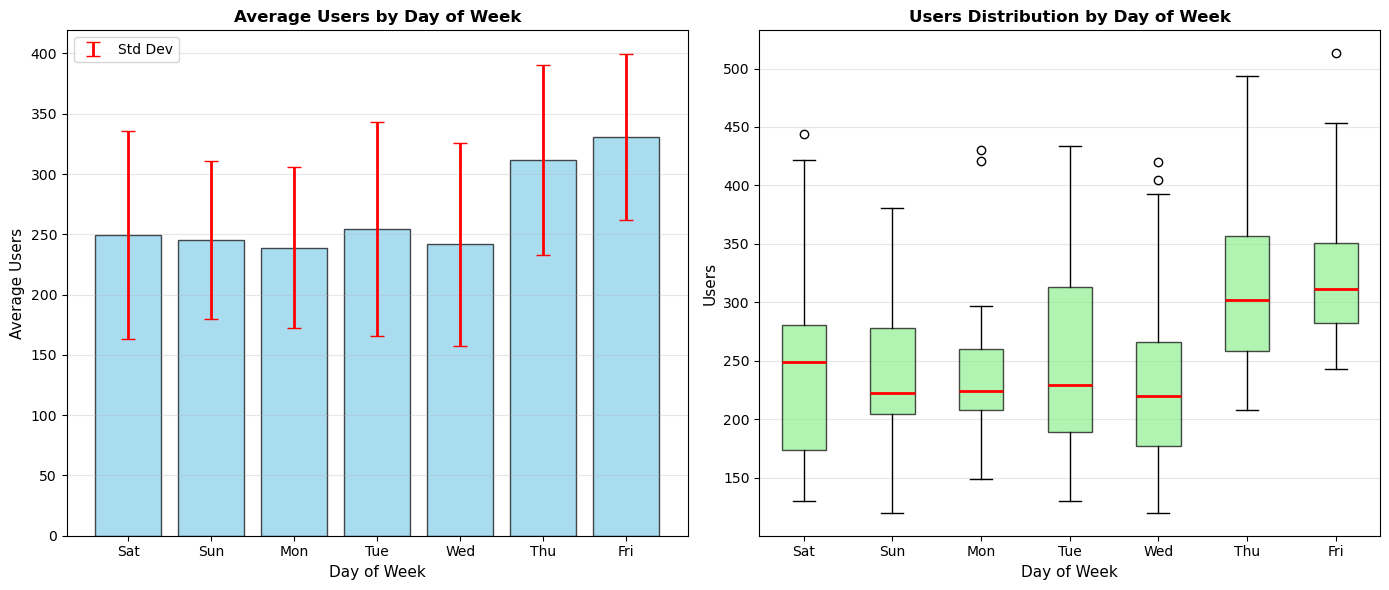

In [7]:
# ============================================================================
# 4.1 Time Series Decomposition
# ============================================================================
print("\n📈 Section 1: Time Series Decomposition")
print("-" * 70)
df = pd.read_csv("app_users_dataset.csv")


# Decompose the Users time series
# period=7 for weekly seasonality
decomposition = seasonal_decompose(df['Users'], model='additive', period=7)

# Extract components
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Original
axes[0].plot(df['Day'], df['Users'], color='blue', linewidth=1.5)
axes[0].set_ylabel('Users', fontsize=11)
axes[0].set_title('Original Time Series', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Trend
axes[1].plot(df['Day'], trend, color='red', linewidth=2)
axes[1].set_ylabel('Trend', fontsize=11)
axes[1].set_title('Trend Component', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Seasonal
axes[2].plot(df['Day'], seasonal, color='green', linewidth=1.5)
axes[2].set_ylabel('Seasonal', fontsize=11)
axes[2].set_title('Seasonal Component (Weekly)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# Residual
axes[3].plot(df['Day'], residual, color='purple', linewidth=1, alpha=0.7)
axes[3].set_xlabel('Day', fontsize=11)
axes[3].set_ylabel('Residual', fontsize=11)
axes[3].set_title('Residual Component', fontsize=12, fontweight='bold')
axes[3].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("images/time_series_decomposition.png", dpi=300, bbox_inches='tight')

# Statistics of components
print(f"\nTime series component statistics:")
print(f"  • Trend range: {trend.min():.2f} to {trend.max():.2f}")
print(f"  • Seasonal range: {seasonal.min():.2f} to {seasonal.max():.2f}")
print(f"  • Residual standard deviation: {residual.std():.2f}")

# ============================================================================
# 4.2 Stationarity Test (Augmented Dickey-Fuller Test)
# ============================================================================
print("\n" + "-" * 70)
print("📊 Section 2: Stationarity Test")
print("-" * 70)

# ADF test for Users
adf_result = adfuller(df['Users'], autolag='AIC')
print(f"\nAugmented Dickey-Fuller test for Users:")
print(f"  • ADF Statistic: {adf_result[0]:.4f}")
print(f"  • p-value: {adf_result[1]:.4f}")
print(f"  • Critical Values:")
for key, value in adf_result[4].items():
    print(f"      {key}: {value:.4f}")

if adf_result[1] < 0.05:
    print(f"\n  ✅ The time series is stationary (p-value < 0.05)")
else:
    print(f"\n  ⚠️  The time series is non-stationary (p-value >= 0.05)")
    print(f"     Differencing can be used to make it stationary")

# Test on differenced series
df['Users_diff'] = df['Users'].diff()
adf_result_diff = adfuller(df['Users_diff'].dropna(), autolag='AIC')
print(f"\nADF test for differenced Users:")
print(f"  • ADF Statistic: {adf_result_diff[0]:.4f}")
print(f"  • p-value: {adf_result_diff[1]:.4f}")

if adf_result_diff[1] < 0.05:
    print(f"  ✅ The differenced series is stationary")

# ============================================================================
# 4.3 Rolling Statistics
# ============================================================================
print("\n" + "-" * 70)
print("📊 Section 4: Rolling Statistics")
print("-" * 70)

# Calculate rolling mean and std
window = 7  # 7-day window
df['Rolling_Mean'] = df['Users'].rolling(window=window).mean()
df['Rolling_Std'] = df['Users'].rolling(window=window).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Rolling mean
axes[0].plot(df['Day'], df['Users'], label='Original', color='blue', alpha=0.5, linewidth=1)
axes[0].plot(df['Day'], df['Rolling_Mean'], label=f'{window}-Day Rolling Mean', color='red', linewidth=2)
axes[0].set_ylabel('Users', fontsize=11)
axes[0].set_title('Rolling Mean (7-Day Window)', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Rolling std
axes[1].plot(df['Day'], df['Rolling_Std'], label=f'{window}-Day Rolling Std', color='green', linewidth=2)
axes[1].set_xlabel('Day', fontsize=11)
axes[1].set_ylabel('Standard Deviation', fontsize=11)
axes[1].set_title('Rolling Standard Deviation (7-Day Window)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("images/rolling_statistics.png", dpi=300, bbox_inches='tight')

print(f"\nRolling statistics:")
print(f"  • Rolling mean shows the overall trend")
print(f"  • Rolling standard deviation shows the fluctuations")
print(f"  • Mean Rolling Std: {df['Rolling_Std'].mean():.2f}")

# ============================================================================
# 4.4 Lag Analysis
# ============================================================================
print("\n" + "-" * 70)
print("🔄 Section 5: Lag Analysis")
print("-" * 70)

# Create lag features
max_lag = 7
lag_correlations = []

for lag in range(1, max_lag + 1):
    df[f'Users_lag{lag}'] = df['Users'].shift(lag)
    corr = df['Users'].corr(df[f'Users_lag{lag}'])
    lag_correlations.append(corr)
    print(f"  • Correlation of Users with lag {lag}: {corr:.4f}")

# Plot lag correlations
fig, ax = plt.subplots(figsize=(10, 6))
lags = list(range(1, max_lag + 1))
colors = ['green' if x > 0.5 else 'orange' if x > 0.3 else 'red' for x in lag_correlations]
ax.bar(lags, lag_correlations, color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Lag (Days)', fontsize=11)
ax.set_ylabel('Correlation with Users', fontsize=11)
ax.set_title('Correlation between Users and Lagged Values', fontsize=12, fontweight='bold')
ax.axhline(y=0.5, color='green', linestyle='--', linewidth=1, label='Strong correlation (>0.5)')
ax.axhline(y=0.3, color='orange', linestyle='--', linewidth=1, label='Moderate correlation (>0.3)')
ax.set_xticks(lags)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("images/lag_correlation.png", dpi=300, bbox_inches='tight')

# ============================================================================
# 4.5 Weekly Pattern Analysis
# ============================================================================
print("\n" + "-" * 70)
print("📅 Section 6: Weekly Pattern Analysis")
print("-" * 70)

# Add day of week (assuming day 1 is Saturday)
df['DayOfWeek'] = ((df['Day'] - 1) % 7)
day_names = ['Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri']
df['DayName'] = df['DayOfWeek'].apply(lambda x: day_names[x])

# Calculate average users by day of week
weekly_pattern = df.groupby('DayName')['Users'].agg(['mean', 'std', 'count']).reindex(day_names)

print("\nAverage Users by day of week:")
for day in day_names:
    mean_val = weekly_pattern.loc[day, 'mean']
    std_val = weekly_pattern.loc[day, 'std']
    print(f"  • {day}: {mean_val:.2f} ± {std_val:.2f}")

# Plot weekly pattern
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot
axes[0].bar(day_names, weekly_pattern['mean'], color='skyblue', alpha=0.7, edgecolor='black')
axes[0].errorbar(day_names, weekly_pattern['mean'], yerr=weekly_pattern['std'],
                 fmt='none', color='red', capsize=5, linewidth=2, label='Std Dev')
axes[0].set_xlabel('Day of Week', fontsize=11)
axes[0].set_ylabel('Average Users', fontsize=11)
axes[0].set_title('Average Users by Day of Week', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Box plot
users_by_day = [df[df['DayName'] == day]['Users'].values for day in day_names]
bp = axes[1].boxplot(users_by_day, labels=day_names, patch_artist=True,
                     boxprops=dict(facecolor='lightgreen', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2))
axes[1].set_xlabel('Day of Week', fontsize=11)
axes[1].set_ylabel('Users', fontsize=11)
axes[1].set_title('Users Distribution by Day of Week', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("images/weekly_pattern.png", dpi=300, bbox_inches='tight')

# ============================================================================
# Summary
# ============================================================================
print("\n" + "=" * 70)
print("Time Series Analysis Summary:")
print("=" * 70)

print("\n🔍 Key Findings:")
print(f"\n1️⃣ Time series components:")
print(f"   • Trend: upward trend with range {trend.min():.1f} to {trend.max():.1f}")
print(f"   • Seasonal: weekly pattern with range {seasonal.min():.1f} to {seasonal.max():.1f}")
print(f"   • Residual: random noise with standard deviation {residual.std():.2f}")

print(f"\n2️⃣ Stationarity:")
if adf_result[1] < 0.05:
    print(f"   • The time series is stationary (p-value = {adf_result[1]:.4f})")
else:
    print(f"   • The time series is non-stationary (p-value = {adf_result[1]:.4f})")
    print(f"   • It becomes stationary after differencing (p-value = {adf_result_diff[1]:.4f})")

print(f"\n3️⃣ Autocorrelation:")
print(f"   • Strong correlation with nearby lags (1-3 days)")
print(f"   • Weekly pattern is visible in the ACF")

print(f"\n4️⃣ Weekly pattern:")
max_day = weekly_pattern['mean'].idxmax()
min_day = weekly_pattern['mean'].idxmin()
print(f"   • Highest Users on {max_day}: {weekly_pattern.loc[max_day, 'mean']:.2f}")
print(f"   • Lowest Users on {min_day}: {weekly_pattern.loc[min_day, 'mean']:.2f}")
print(f"   • Difference: {weekly_pattern.loc[max_day, 'mean'] - weekly_pattern.loc[min_day, 'mean']:.2f}")

print(f"\n5️⃣ Fluctuations:")
print(f"   • Mean rolling standard deviation: {df['Rolling_Std'].mean():.2f}")
print(f"   • Fluctuations are relatively stable over time")





Training SARIMAX model...
SARIMAX training completed successfully!

Model Comparison:
                       Model        MAE       RMSE        R2
1  Linear Regression + Day^2  12.505187  15.864786  0.961923
2                    SARIMAX  12.521809  15.860560  0.960530
0          Linear Regression  19.905146  25.598032  0.900870

Model 1 Coefficients:
         Feature  Coefficient
0            Day     0.191281
1       Ad_Spend     2.820451
2  Ad_Spend_Lag1     1.431418
3     is_weekend    52.790719
Intercept: 157.77575877142482


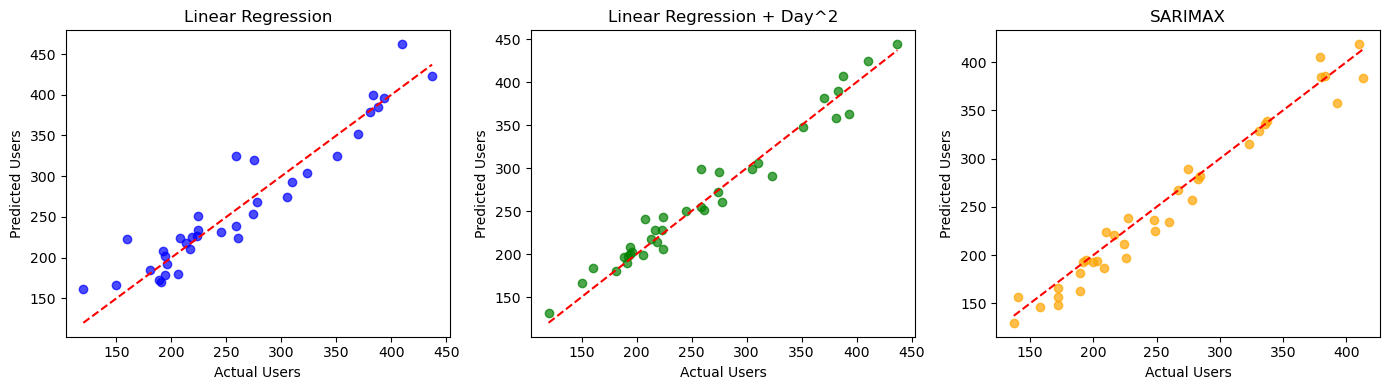

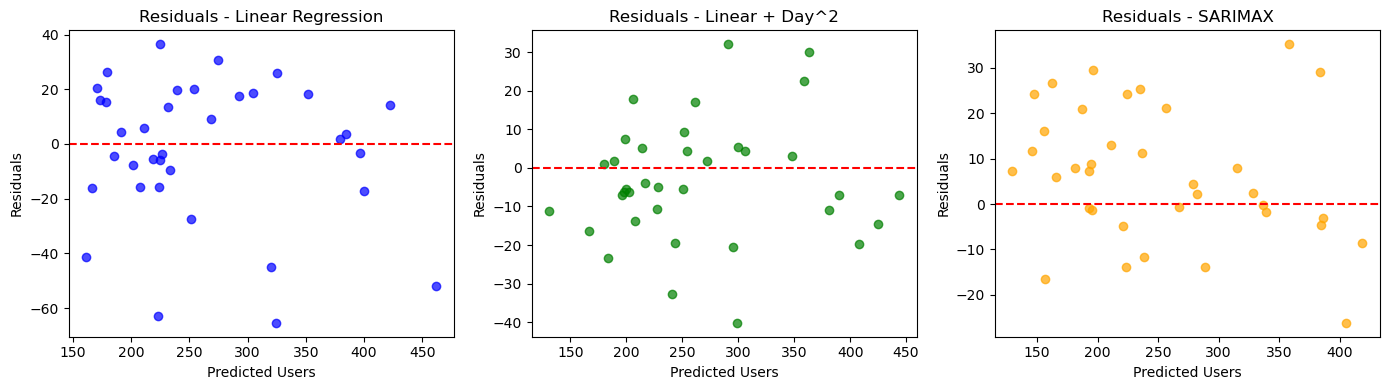

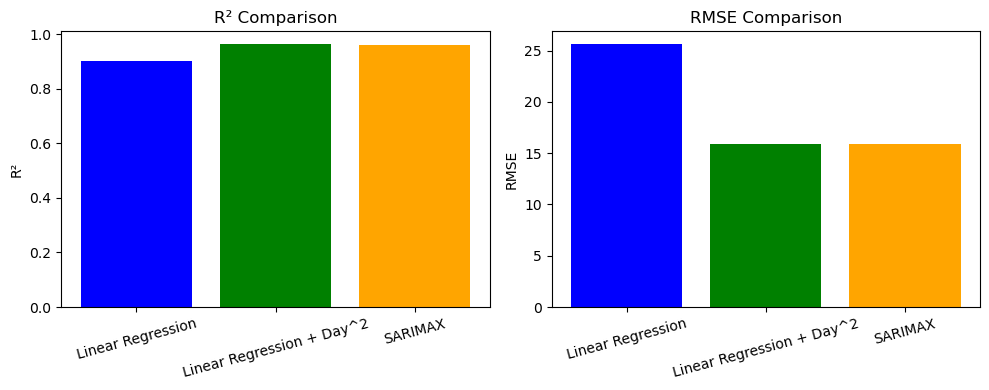

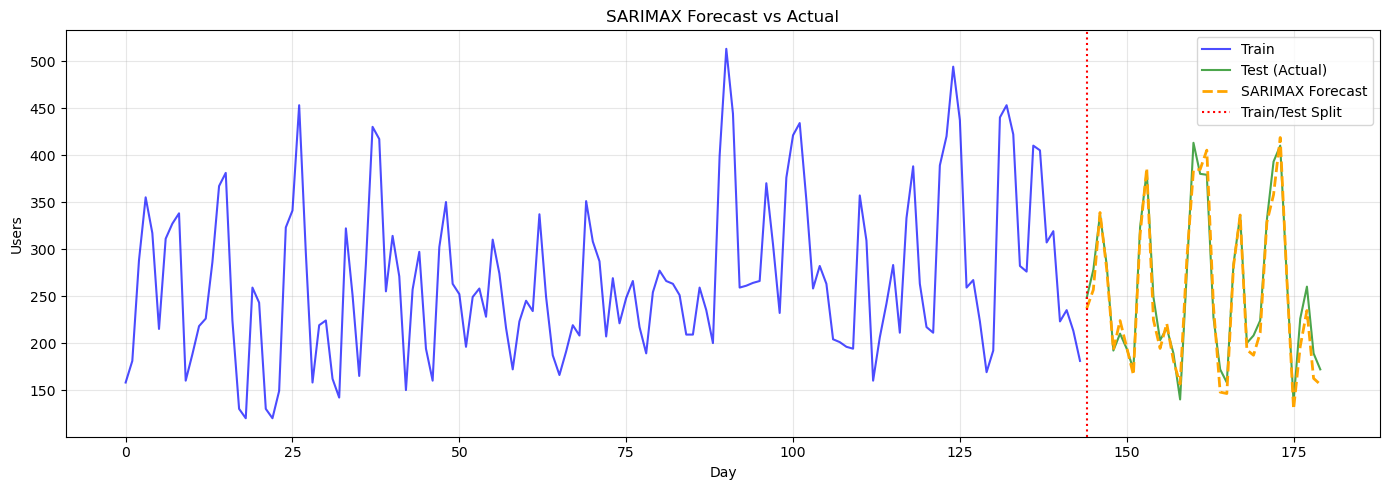


Best Model Based on R²:
Model    Linear Regression + Day^2
MAE                      12.505187
RMSE                     15.864786
R2                        0.961923
Name: 1, dtype: object


In [9]:

# =========================
# 1. Load data from CSV
# =========================
df = pd.read_csv("app_users_dataset.csv")

# =========================
# 2. Define features
# =========================
# Model 1: Simple Linear Regression with original features
features_basic = ["Day", "Ad_Spend", "Ad_Spend_Lag1", "is_weekend"]

# Model 2 and Model 3 (SARIMAX): add Day^2
df["Day_Squared"] = df["Day"] ** 2
features_with_square = ["Day", "Day_Squared", "Ad_Spend", "Ad_Spend_Lag1", "is_weekend"]

target = "Users"

X_basic = df[features_basic]
X_square = df[features_with_square]
y = df[target]

# =========================
# 3. Train-test split
# =========================
train_size = int(len(df) * 0.8)

# For regression models (random split)
indices = np.arange(len(df))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

X_basic_train = X_basic.iloc[train_idx]
X_basic_test = X_basic.iloc[test_idx]

X_square_train = X_square.iloc[train_idx]
X_square_test = X_square.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# For SARIMAX (sequential split)
y_train_seq = y[:train_size]
y_test_seq = y[train_size:]
X_train_seq = X_square[:train_size]
X_test_seq = X_square[train_size:]

# =========================
# 4. Build models
# =========================
model_1 = LinearRegression()
model_2 = LinearRegression()

# =========================
# 5. Train models
# =========================
model_1.fit(X_basic_train, y_train)
model_2.fit(X_square_train, y_train)

# =========================
# 5b. Train SARIMAX model
# =========================
print("\n" + "=" * 70)
print("Training SARIMAX model...")

try:
    model_3 = SARIMAX(
        y_train_seq,
        exog=X_train_seq,
        order=(2, 1, 2),
        seasonal_order=(1, 0, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    model_3_fit = model_3.fit(disp=False, maxiter=200)
    print("SARIMAX training completed successfully!")
    
    # Predictions
    y_pred_3 = model_3_fit.forecast(steps=len(y_test_seq), exog=X_test_seq)
    
    sarimax_success = True
except Exception as e:
    print(f"SARIMAX training failed: {e}")
    sarimax_success = False

# =========================
# 6. Predictions
# =========================
y_pred_1 = model_1.predict(X_basic_test)
y_pred_2 = model_2.predict(X_square_test)

# =========================
# 7. Evaluation function
# =========================
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

results = []
results.append(evaluate_model(y_test, y_pred_1, "Linear Regression"))
results.append(evaluate_model(y_test, y_pred_2, "Linear Regression + Day^2"))

if sarimax_success:
    results.append(evaluate_model(y_test_seq, y_pred_3, "SARIMAX"))

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("Model Comparison:")
print(results_df.sort_values(by="R2", ascending=False))

# =========================
# 8. Print coefficients
# =========================
print("\n" + "=" * 70)
print("Model 1 Coefficients:")
coef_1 = pd.DataFrame({
    "Feature": features_basic,
    "Coefficient": model_1.coef_
})
print(coef_1)
print("Intercept:", model_1.intercept_)

# =========================
# 9. Plot Actual vs Predicted
# =========================
n_models = 3 if sarimax_success else 2
fig_width = 14 if sarimax_success else 10

plt.figure(figsize=(fig_width, 4))

plt.subplot(1, n_models, 1)
plt.scatter(y_test, y_pred_1, alpha=0.7, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Users")
plt.ylabel("Predicted Users")
plt.title("Linear Regression")

plt.subplot(1, n_models, 2)
plt.scatter(y_test, y_pred_2, alpha=0.7, color="green")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Users")
plt.ylabel("Predicted Users")
plt.title("Linear Regression + Day^2")

if sarimax_success:
    plt.subplot(1, n_models, 3)
    plt.scatter(y_test_seq, y_pred_3, alpha=0.7, color="orange")
    plt.plot([y_test_seq.min(), y_test_seq.max()], [y_test_seq.min(), y_test_seq.max()], "r--")
    plt.xlabel("Actual Users")
    plt.ylabel("Predicted Users")
    plt.title("SARIMAX")

plt.tight_layout()
plt.savefig("images/actual_vs_predicted_models.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 10. Residual plots
# =========================
residuals_1 = y_test - y_pred_1
residuals_2 = y_test - y_pred_2

plt.figure(figsize=(fig_width, 4))

plt.subplot(1, n_models, 1)
plt.scatter(y_pred_1, residuals_1, alpha=0.7, color="blue")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Users")
plt.ylabel("Residuals")
plt.title("Residuals - Linear Regression")

plt.subplot(1, n_models, 2)
plt.scatter(y_pred_2, residuals_2, alpha=0.7, color="green")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Users")
plt.ylabel("Residuals")
plt.title("Residuals - Linear + Day^2")

if sarimax_success:
    residuals_3 = y_test_seq - y_pred_3
    plt.subplot(1, n_models, 3)
    plt.scatter(y_pred_3, residuals_3, alpha=0.7, color="orange")
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Predicted Users")
    plt.ylabel("Residuals")
    plt.title("Residuals - SARIMAX")

plt.tight_layout()
plt.savefig("images/residual_plots_models.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 11. Compare model metrics
# =========================
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
colors = ["blue", "green", "orange"][:len(results_df)]
plt.bar(results_df["Model"], results_df["R2"], color=colors)
plt.title("R² Comparison")
plt.ylabel("R²")
plt.xticks(rotation=15)

plt.subplot(1, 2, 2)
plt.bar(results_df["Model"], results_df["RMSE"], color=colors)
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig("images/model_comparison_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 12. Time series forecast plot (SARIMAX)
# =========================
if sarimax_success:
    plt.figure(figsize=(14, 5))
    
    # Plot training data
    plt.plot(range(len(y_train_seq)), y_train_seq, label="Train", color="blue", alpha=0.7)
    
    # Plot test data
    test_range = range(len(y_train_seq), len(y_train_seq) + len(y_test_seq))
    plt.plot(test_range, y_test_seq, label="Test (Actual)", color="green", alpha=0.7)
    
    # Plot SARIMAX predictions
    plt.plot(test_range, y_pred_3, label="SARIMAX Forecast", color="orange", linestyle="--", linewidth=2)
    
    plt.axvline(x=len(y_train_seq), color="red", linestyle=":", label="Train/Test Split")
    plt.xlabel("Day")
    plt.ylabel("Users")
    plt.title("SARIMAX Forecast vs Actual")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("images/sarimax_forecast.png", dpi=300, bbox_inches="tight")
    plt.show()

# =========================
# 13. Final conclusion
# =========================
best_model = results_df.sort_values(by="R2", ascending=False).iloc[0]

print("\n" + "=" * 70)
print("Best Model Based on R²:")
print(best_model)
